<a href="https://colab.research.google.com/github/Charlsz/taller01/blob/main/Taller02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Árbol de entrada (lista anidada de Python)
# La lista más externa son los hijos de la raíz (nodo MAX)
try:
    import itertools
    import math
    import random
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
except ImportError:
    %pip install matplotlib
    import itertools
    import math
    import random
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

arbol_entrada = [[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]


In [3]:
def construir_arbol(lista, nivel=0, jugador="MAX", nodos=None, contador=None):
    """
    Convierte una lista anidada de Python en un árbol explícito
    que puede recorrerse con el algoritmo de poda alfa-beta

    - La raíz corresponde a la lista completa recibida y es de tipo MAX.
    - Cada elemento de una lista es un hijo: si es una lista -> nodo interno
      (alternando MIN/MAX); si es un número -> nodo hoja
    """
    if nodos is None:
        nodos = {}
    if contador is None:
        contador = itertools.count()

    id_nodo = next(contador)

    if isinstance(lista, (int, float)):
        nodos[id_nodo] = {
            "id": id_nodo, "nivel": nivel, "jugador": jugador,
            "es_hoja": True, "valor": lista, "hijos": []
        }
        return id_nodo, nodos, contador

    nodos[id_nodo] = {
        "id": id_nodo, "nivel": nivel, "jugador": jugador,
        "es_hoja": False, "valor": None, "hijos": []
    }
    hijo_jugador = "MIN" if jugador == "MAX" else "MAX"
    for elem in lista:
        id_hijo, nodos, contador = construir_arbol(elem, nivel + 1, hijo_jugador, nodos, contador)
        nodos[id_nodo]["hijos"].append(id_hijo)
    return id_nodo, nodos, contador


In [4]:
def poda_alfa_beta(nodos, id_nodo, alfa=-math.inf, beta=math.inf,
                    visitados=None, podados=None):
    if visitados is None:
        visitados = set()
    if podados is None:
        podados = set()

    nodo = nodos[id_nodo]
    visitados.add(id_nodo)

    # Caso base: nodo hoja -> se retorna su valor (heuristica/utilidad)
    if nodo["es_hoja"]:
        nodo["valor_calculado"] = nodo["valor"]
        return nodo["valor"], visitados, podados

    maximizando = (nodo["jugador"] == "MAX")
    mejor = -math.inf if maximizando else math.inf
    mejor_hijo = None

    for i, id_hijo in enumerate(nodo["hijos"]):
        valor_hijo, visitados, podados = poda_alfa_beta(
            nodos, id_hijo, alfa, beta, visitados, podados
        )
        if maximizando:
            if valor_hijo > mejor:
                mejor = valor_hijo
                mejor_hijo = id_hijo
            alfa = max(alfa, mejor)
        else:
            if valor_hijo < mejor:
                mejor = valor_hijo
                mejor_hijo = id_hijo
            beta = min(beta, mejor)

        # Condicion de poda
        if beta <= alfa:
            for id_restante in nodo["hijos"][i + 1:]:
                marcar_podado(nodos, id_restante, podados)
            break

    nodo["valor_calculado"] = mejor
    nodo["mejor_hijo"] = mejor_hijo
    return mejor, visitados, podados


def marcar_podado(nodos, id_nodo, podados):
    """Marca recursivamente un subarbol completo como podado (nunca visitado)."""
    podados.add(id_nodo)
    for id_hijo in nodos[id_nodo]["hijos"]:
        marcar_podado(nodos, id_hijo, podados)


def camino_optimo(nodos, id_raiz):
    """Reconstruye la secuencia optima de jugadas desde la raiz hasta una hoja."""
    camino = [id_raiz]
    actual = nodos[id_raiz]
    while not actual["es_hoja"]:
        siguiente = actual["mejor_hijo"]
        camino.append(siguiente)
        actual = nodos[siguiente]
    return camino


In [5]:
def _particionar(n, k):
    """Divide el entero n en k partes enteras positivas, elegidas al azar"""
    if k == 1:
        return [n]
    cortes = sorted(random.sample(range(1, n), k - 1))
    partes, anterior = [], 0
    for c in cortes:
        partes.append(c - anterior)
        anterior = c
    partes.append(n - anterior)
    return partes


def generar_arbol_aleatorio(niveles, nodos_hoja, rango=(-20, 20), max_ramas=4):
    """
    Genera una lista anidada de Python con 'niveles' niveles y exactamente 'nodos_hoja' nodos hoja en total,
    con valores aleatorios en 'rango'

    """
    assert 2 <= niveles <= 5, "El arbol debe tener entre 2 y 5 niveles"
    assert 2 <= nodos_hoja <= 50, "El arbol debe tener entre 2 y 50 nodos hoja"

    def construir(n, niveles_restantes):
        if niveles_restantes == 1:
            return random.randint(*rango)
        max_k = min(max_ramas, n)
        min_k = min(2, n)
        k = random.randint(min_k, max_k) if max_k >= min_k else 1
        partes = _particionar(n, k)
        return [construir(p, niveles_restantes - 1) for p in partes]

    return construir(nodos_hoja, niveles)


In [6]:
def _asignar_posiciones(nodos, id_nodo, contador_x):
    nodo = nodos[id_nodo]
    if not nodo["hijos"]:
        x = next(contador_x)
        nodo["x"] = x
        return x
    xs = [_asignar_posiciones(nodos, h, contador_x) for h in nodo["hijos"]]
    nodo["x"] = sum(xs) / len(xs)
    return nodo["x"]


def dibujar_arbol(nodos, id_raiz, podados, camino, titulo="", figsize=None):
    contador_x = itertools.count()
    _asignar_posiciones(nodos, id_raiz, contador_x)
    n_hojas = max(n["x"] for n in nodos.values()) + 1
    n_niveles = max(n["nivel"] for n in nodos.values()) + 1
    if figsize is None:
        figsize = (max(8, n_hojas * 1.1), max(5, n_niveles * 1.9))

    fig, ax = plt.subplots(figsize=figsize)
    camino_edges = set(zip(camino, camino[1:]))
    camino_set = set(camino)

    # Aristas
    for nid, nodo in nodos.items():
        for hid in nodo["hijos"]:
            hijo = nodos[hid]
            x1, y1 = nodo["x"], -nodo["nivel"]
            x2, y2 = hijo["x"], -hijo["nivel"]
            if hid in podados:
                ax.plot([x1, x2], [y1, y2], color="red", linestyle="--", linewidth=1.3, zorder=1)
            elif (nid, hid) in camino_edges:
                ax.plot([x1, x2], [y1, y2], color="green", linewidth=2.8, zorder=2)
            else:
                ax.plot([x1, x2], [y1, y2], color="gray", linewidth=1.0, zorder=1)

    # Nodos
    for nid, nodo in nodos.items():
        x, y = nodo["x"], -nodo["nivel"]
        if nid in podados:
            face, edge = "#f8d7da", "red"
        elif nid in camino_set:
            face, edge = "#c8f7c5", "green"
        else:
            face, edge = "white", "black"

        if nodo["es_hoja"]:
            texto = str(nodo["valor"])
            ax.scatter([x], [y], s=900, marker="v", color=face, edgecolors=edge, linewidths=1.8, zorder=3)
        else:
            marker = "^" if nodo["jugador"] == "MAX" else "v"
            texto = f"{nodo.get('valor_calculado', '')}"
            ax.scatter([x], [y], s=1100, marker=marker, color=face, edgecolors=edge, linewidths=1.8, zorder=3)
        ax.text(x, y - 0.28, texto, ha="center", va="top", fontsize=9, fontweight="bold", zorder=4)

    ax.set_title(titulo, fontsize=13)
    ax.axis("off")
    ax.set_ylim(ax.get_ylim()[0] - 0.9, ax.get_ylim()[1] + 0.3)
    leyenda = [
        mpatches.Patch(facecolor="#c8f7c5", edgecolor="green", label="Camino / jugada óptima"),
        mpatches.Patch(facecolor="#f8d7da", edgecolor="red", label="Rama podada"),
        mpatches.Patch(facecolor="white", edgecolor="black", label="Nodo explorado"),
    ]
    ax.legend(handles=leyenda, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False, fontsize=9)
    plt.tight_layout()
    return fig


In [7]:
raiz, nodos, _ = construir_arbol(arbol_entrada)
valor_optimo, visitados, podados = poda_alfa_beta(nodos, raiz)
camino = camino_optimo(nodos, raiz)

print("Árbol de entrada:", arbol_entrada)
print("Valor óptimo (resultado del minimax en la raíz):", valor_optimo)
print(f"Nodos totales: {len(nodos)} | Visitados: {len(visitados)} | Podados: {len(podados)}")
print()
print("Secuencia óptima de jugadas (raíz -> hoja):")
for nid in camino:
    n = nodos[nid]
    tipo = "HOJA" if n["es_hoja"] else f"nodo {n['jugador']}"
    print(f"  nivel {n['nivel']:>1} | {tipo:<9} | valor = {n['valor_calculado']}")


Árbol de entrada: [[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]
Valor óptimo (resultado del minimax en la raíz): -5
Nodos totales: 13 | Visitados: 9 | Podados: 4

Secuencia óptima de jugadas (raíz -> hoja):
  nivel 0 | nodo MAX  | valor = -5
  nivel 1 | nodo MIN  | valor = -5
  nivel 2 | HOJA      | valor = -5


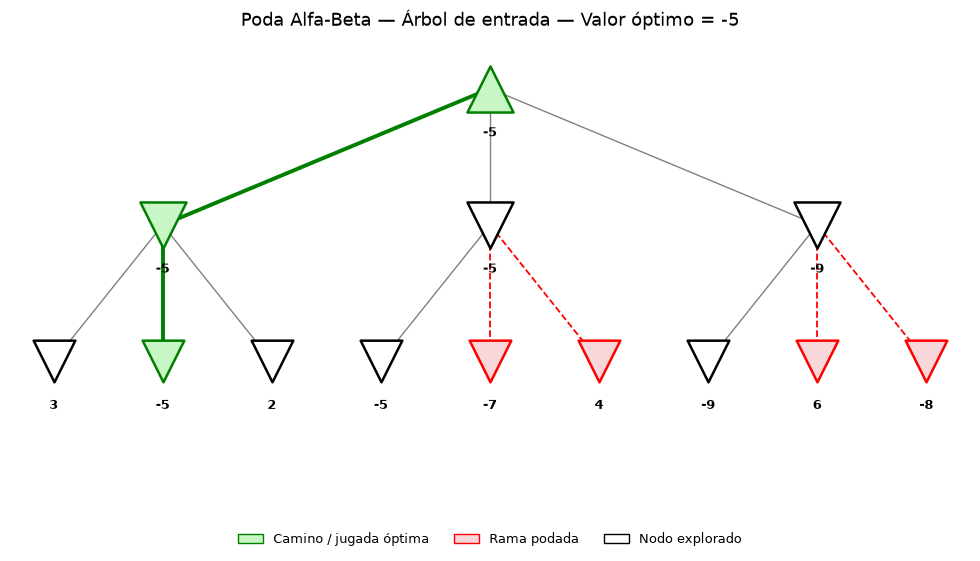

In [8]:
fig = dibujar_arbol(nodos, raiz, podados, camino,
                     titulo=f"Poda Alfa-Beta — Árbol de entrada — Valor óptimo = {valor_optimo}")
plt.show()


In [9]:
random.seed(7)  # fijar semilla solo para reproducibilidad del ejemplo; se puede quitar

niveles_deseados = 4
hojas_deseadas = 24

arbol_aleatorio = generar_arbol_aleatorio(niveles_deseados, hojas_deseadas, rango=(-20, 20))
print("Árbol aleatorio generado:")
print(arbol_aleatorio)


Árbol aleatorio generado:
[[[17], [-18, -15], [6], [-5]], [[-13, -6, 20], [-17, -6]], [[6, -11], [15, -9]]]


Valor óptimo: 6
Nodos totales: 26 | Visitados: 25 | Podados: 1


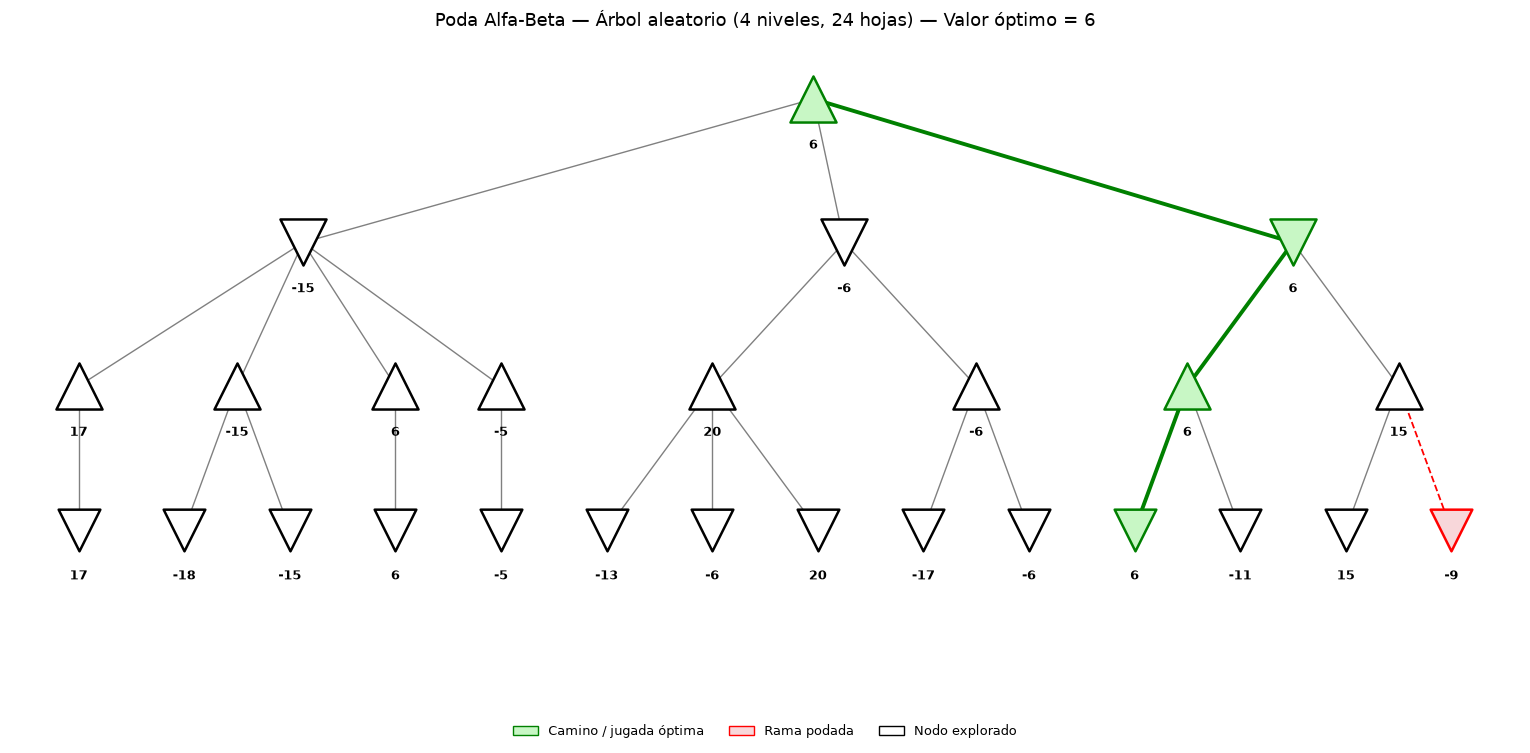

In [10]:
raiz_r, nodos_r, _ = construir_arbol(arbol_aleatorio)
valor_r, visitados_r, podados_r = poda_alfa_beta(nodos_r, raiz_r)
camino_r = camino_optimo(nodos_r, raiz_r)

print("Valor óptimo:", valor_r)
print(f"Nodos totales: {len(nodos_r)} | Visitados: {len(visitados_r)} | Podados: {len(podados_r)}")

fig = dibujar_arbol(nodos_r, raiz_r, podados_r, camino_r,
                     titulo=(f"Poda Alfa-Beta — Árbol aleatorio "
                             f"({niveles_deseados} niveles, {hojas_deseadas} hojas) — "
                             f"Valor óptimo = {valor_r}"))
plt.show()


## Prueba con un árbol grande (máximos del enunciado: 5 niveles, 50 hojas)



Total de nodos en el árbol: 57
Nodos visitados por la poda alfa-beta: 20
Nodos podados (nunca generados/evaluados): 37
Porcentaje de nodos ahorrados: 64.9%
Valor óptimo encontrado: 18


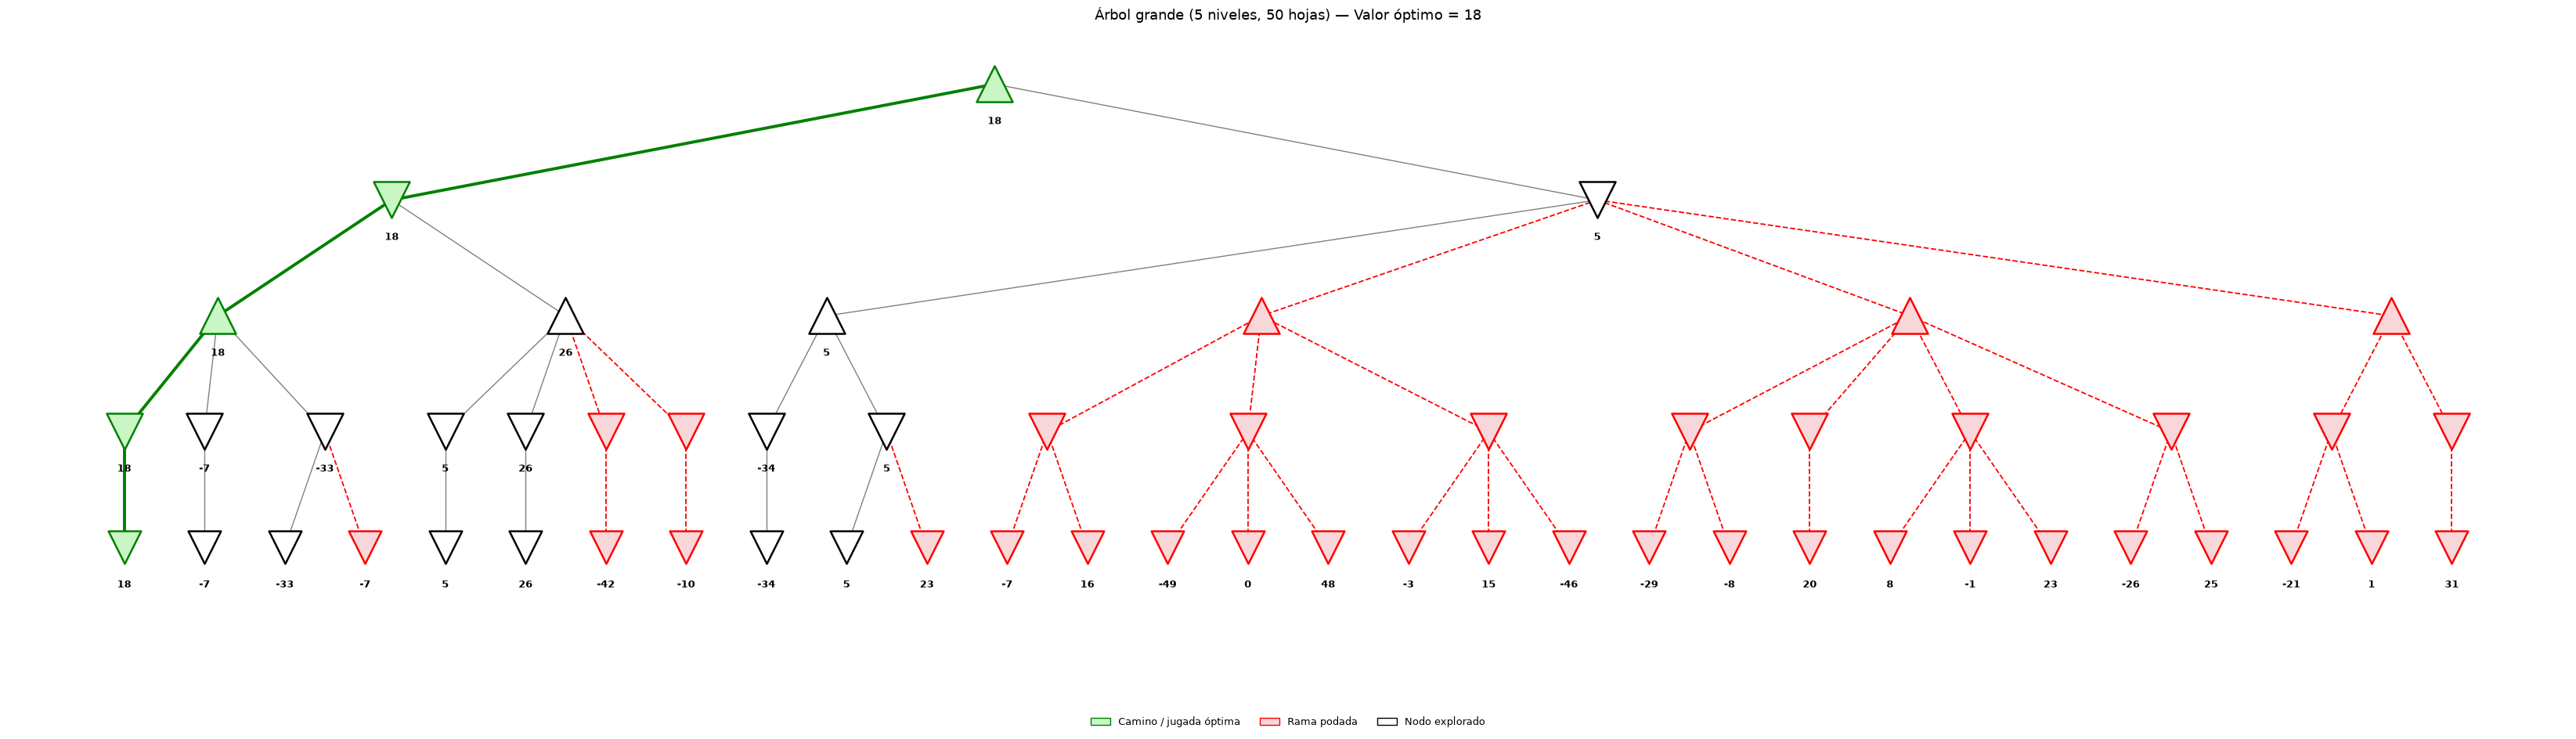

In [11]:
random.seed(123)
arbol_grande = generar_arbol_aleatorio(5, 50, rango=(-50, 50))
raiz_g, nodos_g, _ = construir_arbol(arbol_grande)
valor_g, visitados_g, podados_g = poda_alfa_beta(nodos_g, raiz_g)

total = len(nodos_g)
print(f"Total de nodos en el árbol: {total}")
print(f"Nodos visitados por la poda alfa-beta: {len(visitados_g)}")
print(f"Nodos podados (nunca generados/evaluados): {len(podados_g)}")
print(f"Porcentaje de nodos ahorrados: {len(podados_g)/total*100:.1f}%")
print(f"Valor óptimo encontrado: {valor_g}")

fig = dibujar_arbol(nodos_g, raiz_g, podados_g, camino_optimo(nodos_g, raiz_g),
                     titulo=f"Árbol grande (5 niveles, 50 hojas) — Valor óptimo = {valor_g}")
plt.show()
